# CLOTHING SIZE RECOMMENDATION MODEL


## 1.O INTRODUCTION

### 1.1 Project Overview

This guide walks you through building a size-recommendation ML model. Buyers input personal measurements — height, waist, shoulders, bust, hips, weight — and receive accurate size suggestions. The model learns from 270,000+ real-world fit records across two open datasets.


What the Model Will Do:


  Accept buyer measurements: height, weight, waist, shoulder width, bust, hips, age


  Predict whether an item will FIT, be TOO SMALL, or TOO LARGE

  Recommend the optimal size (XS / S / M / L / XL or numeric) per garment category


  Generalize across brands and categories (dresses, tops, bottoms, jackets, etc.)


  Improve automatically as more purchase feedback is collected


### 1.2 Business Understanding

In online fashion retail, incorrect sizing is one of the leading causes of product returns and customer dissatisfaction. Buyers often struggle to select the right size because sizing standards vary across brands and garment categories. This project aims to solve this problem by developing a machine learning size-recommendation system that uses customer body measurements (such as height, weight, waist, shoulders, bust, hips, and age) to predict whether a garment will **fit**, be **too small**, or **too large**, and recommend the most appropriate size. By improving size accuracy, the model helps clothing companies reduce return rates, increase customer satisfaction, and enhance the overall online shopping experience.
```


### 2.0 Data Understanding


In this stage, we explore the two datasets used to train the clothing size recommendation model: **modcloth_final_data** and **renttherunway_final_data**. These datasets contain real-world customer fit feedback and body measurements that help understand how different body types correspond to clothing sizes.

The **modcloth_final_data** dataset includes customer information such as height, weight, body type, and feedback on whether the clothing item fit correctly. The **renttherunway_final_data** dataset provides similar attributes including size, fit feedback, body measurements (bust, waist, hips), and user reviews.

By examining these datasets, we aim to:
- Understand the structure and key variables in each dataset.
- Identify important features related to body measurements and fit outcomes.
- Check for missing values and inconsistencies.
- Gain insights that will guide data cleaning, feature selection, and model development.

This exploration helps ensure the data is suitable for building a reliable size recommendation system.


### 2.1 Data preview

In [14]:
# import necessary libraries 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# Load data1
import pandas as pd

mc = pd.read_json('modcloth_final_data.json', lines=True)
print(mc.head())




   item_id  waist  size  quality cup size  hips  bra size category bust  \
0   123373   29.0     7      5.0        d  38.0      34.0      new   36   
1   123373   31.0    13      3.0        b  30.0      36.0      new  NaN   
2   123373   30.0     7      2.0        b   NaN      32.0      new  NaN   
3   123373    NaN    21      5.0     dd/e   NaN       NaN      new  NaN   
4   123373    NaN    18      5.0        b   NaN      36.0      new  NaN   

    height         user_name         length    fit  user_id  shoe size  \
0  5ft 6in             Emily     just right  small   991571        NaN   
1  5ft 2in  sydneybraden2001     just right  small   587883        NaN   
2  5ft 7in             Ugggh  slightly long  small   395665        9.0   
3      NaN      alexmeyer626     just right    fit   875643        NaN   
4  5ft 2in        dberrones1  slightly long  small   944840        NaN   

  shoe width review_summary review_text  
0        NaN            NaN         NaN  
1        NaN        

In [ ]:

# Load data2

rtr = pd.read_json('renttherunway_final_data.json', lines=True)
print(rtr.head())


   fit  user_id bust size  item_id  weight  rating     rented for  \
0  fit   420272       34d  2260466  137lbs    10.0       vacation   
1  fit   273551       34b   153475  132lbs    10.0          other   
2  fit   360448       NaN  1063761     NaN    10.0          party   
3  fit   909926       34c   126335  135lbs     8.0  formal affair   
4  fit   151944       34b   616682  145lbs    10.0        wedding   

                                         review_text          body type  \
0  An adorable romper! Belt and zipper were a lit...          hourglass   
1  I rented this dress for a photo shoot. The the...  straight & narrow   
2  This hugged in all the right places! It was a ...                NaN   
3  I rented this for my company's black tie award...               pear   
4  I have always been petite in my upper body and...           athletic   

                                      review_summary category height  size  \
0                               So many compliments!   r

## 2.2 Combining the Datasets

Here's what the script does across its 10 steps:
Loading & inspection — reads both JSON files and prints shapes and column names so you can verify what came in.
Column normalisation — renames columns from both sources to a shared schema (bust, waist, hips, quality, etc.) so they stack cleanly.
Source tagging — adds a source column (modcloth / renttherunway) so you can always trace a row back to its origin.
Fit label standardisation — maps both datasets' inconsistent fit labels ("Just Right", "small", "Large", etc.) to three clean classes: fit, too_small, too_large.
Unit conversions:

Height: ModCloth's "5ft 4in" strings and RTR's inch floats both → centimetres
Weight: pound strings/floats from both → kilograms

Output — saves the combined result as both .csv and .json (line-delimited) for flexibility.

In [1]:
import pandas as pd
import numpy as np

# ── 1. Load datasets ──────────────────────────────────────────────────────────
mc  = pd.read_json('modcloth_final_data.json',    lines=True)
rtr = pd.read_json('renttherunway_final_data.json', lines=True)

print("ModCloth shape     :", mc.shape)
print("RentTheRunway shape:", rtr.shape)
print("\nModCloth columns:\n",  mc.columns.tolist())
print("\nRentTheRunway columns:\n", rtr.columns.tolist())


# ── 2. Normalise column names ─────────────────────────────────────────────────
# ModCloth → uniform names
mc_renamed = mc.rename(columns={
    'size'       : 'size',
    'fit'        : 'fit',
    'user_id'    : 'user_id',
    'item_id'    : 'item_id',
    'waist'      : 'waist',
    'hips'       : 'hips',
    'bra_size'   : 'bust',          # closest equivalent
    'height'     : 'height',
    'weight'     : 'weight',
    'age'        : 'age',
    'body_type'  : 'body_type',
    'category'   : 'category',
    'quality'    : 'quality',
})

# RentTheRunway → uniform names
rtr_renamed = rtr.rename(columns={
    'size'       : 'size',
    'fit'        : 'fit',
    'user_id'    : 'user_id',
    'item_id'    : 'item_id',
    'bust'       : 'bust',
    'waist'      : 'waist',
    'hips'       : 'hips',
    'height'     : 'height',
    'weight'     : 'weight',
    'age'        : 'age',
    'body_type'  : 'body_type',
    'category'   : 'category',
    'rating'     : 'quality',       # closest equivalent
})


# ── 3. Add source column ──────────────────────────────────────────────────────
mc_renamed['source']  = 'modcloth'
rtr_renamed['source'] = 'renttherunway'


# ── 4. Keep only shared / useful columns ─────────────────────────────────────
KEEP_COLS = [
    'source', 'user_id', 'item_id', 'category',
    'size', 'fit',
    'height', 'weight', 'age',
    'bust', 'waist', 'hips',
    'body_type', 'quality',
]

mc_slim  = mc_renamed.reindex(columns=KEEP_COLS)
rtr_slim = rtr_renamed.reindex(columns=KEEP_COLS)


# ── 5. Standardise the 'fit' label ───────────────────────────────────────────
FIT_MAP = {
    'fit'       : 'fit',
    'small'     : 'too_small',
    'large'     : 'too_large',
    'Just Right': 'fit',
    'Too Small' : 'too_small',
    'Too Large' : 'too_large',
}

for df in [mc_slim, rtr_slim]:
    df['fit'] = df['fit'].map(FIT_MAP).fillna(df['fit'])


# ── 6. Standardise height → centimetres ──────────────────────────────────────
# ModCloth stores height as "5ft 4in" strings; RTR stores inches as floats.

def parse_mc_height(val):
    """Convert '5ft 4in' or '5ft' strings to centimetres."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    feet = inches = 0
    if 'ft' in val:
        parts = val.replace('in', '').split('ft')
        feet = float(parts[0].strip()) if parts[0].strip() else 0
        inches = float(parts[1].strip()) if len(parts) > 1 and parts[1].strip() else 0
    else:
        try:
            return float(val)   # already numeric
        except ValueError:
            return np.nan
    return round((feet * 12 + inches) * 2.54, 1)

def parse_rtr_height(val):
    """RTR heights are stored in inches (float); convert to centimetres."""
    try:
        return round(float(val) * 2.54, 1)
    except (TypeError, ValueError):
        return np.nan

mc_slim  = mc_slim.copy()
rtr_slim = rtr_slim.copy()

mc_slim['height']  = mc_slim['height'].apply(parse_mc_height)
rtr_slim['height'] = rtr_slim['height'].apply(parse_rtr_height)


# ── 7. Standardise weight → kilograms ────────────────────────────────────────
# Both datasets store weight in pounds (some as "XXXlbs" strings).

def to_kg(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).lower().replace('lbs', '').replace('lb', '').strip()
    try:
        return round(float(val_str) * 0.453592, 1)
    except ValueError:
        return np.nan

mc_slim['weight']  = mc_slim['weight'].apply(to_kg)
rtr_slim['weight'] = rtr_slim['weight'].apply(to_kg)


# ── 8. Concatenate ────────────────────────────────────────────────────────────
combined = pd.concat([mc_slim, rtr_slim], ignore_index=True)

print("\n── Combined Dataset ──────────────────────────────────────────────────")
print("Shape           :", combined.shape)
print("Fit distribution:\n", combined['fit'].value_counts())
print("Source split    :\n", combined['source'].value_counts())
print("\nMissing values  :\n", combined.isnull().sum())


# ── 9. Drop rows with no fit label (model target) ────────────────────────────
combined.dropna(subset=['fit'], inplace=True)
print("\nShape after dropping missing 'fit':", combined.shape)


# ── 10. Save ──────────────────────────────────────────────────────────────────
combined.to_csv('combined_clothing_data.csv', index=False)
combined.to_json('combined_clothing_data.json', orient='records', lines=True)

print("\n✓ Saved → combined_clothing_data.csv")
print("✓ Saved → combined_clothing_data.json")
print("\nPreview:")
print(combined.head())

ModCloth shape     : (82790, 18)
RentTheRunway shape: (192544, 15)

ModCloth columns:
 ['item_id', 'waist', 'size', 'quality', 'cup size', 'hips', 'bra size', 'category', 'bust', 'height', 'user_name', 'length', 'fit', 'user_id', 'shoe size', 'shoe width', 'review_summary', 'review_text']

RentTheRunway columns:
 ['fit', 'user_id', 'bust size', 'item_id', 'weight', 'rating', 'rented for', 'review_text', 'body type', 'review_summary', 'category', 'height', 'size', 'age', 'review_date']

── Combined Dataset ──────────────────────────────────────────────────
Shape           : (275334, 14)
Fit distribution:
 fit
fit          198815
too_small     38753
too_large     37766
Name: count, dtype: int64
Source split    :
 source
renttherunway    192544
modcloth          82790
Name: count, dtype: int64

Missing values  :
 source            0
user_id           0
item_id           0
category          0
size              0
fit               0
height       193651
weight       112772
age           8375

## 3.0 CLEAN AND ENGINEER FEATURES


In [4]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
# 3.0  CLEAN AND ENGINEER FEATURES
# ══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv('combined_clothing_data.csv')
print("Loaded shape:", df.shape)


# ══════════════════════════════════════════════════════════════════════════════
# PRE-STEP  PARSE MESSY NUMERIC STRINGS → float BEFORE ANY IMPUTATION
# Handles: "37-39" (ranges), "34B" (bra sizes), "145lbs", "170cm", plain ints
# ══════════════════════════════════════════════════════════════════════════════

def parse_numeric(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    for unit in ['lbs', 'lb', 'kg', 'cm', 'in', '"', "'"]:
        s = s.replace(unit, '').strip()
    # Bra size e.g. "34b", "32c" → band number only
    bra = re.match(r'^(\d+)[a-z]+$', s)
    if bra:
        return float(bra.group(1))
    # Range e.g. "37-39" → midpoint
    rng = re.match(r'^([\d.]+)\s*[-–]\s*([\d.]+)$', s)
    if rng:
        return round((float(rng.group(1)) + float(rng.group(2))) / 2, 1)
    try:
        return float(s)
    except ValueError:
        return np.nan

NUMERIC_MEASUREMENTS = ['height', 'weight', 'bust', 'waist', 'hips', 'age']

print("\n── Pre-step: parsing messy strings ─────────────────────────────────")
for col in NUMERIC_MEASUREMENTS:
    if col in df.columns:
        before = df[col].isna().sum()
        df[col] = df[col].apply(parse_numeric)
        after  = df[col].isna().sum()
        print(f"  {col:8s}  dtype={df[col].dtype}  nulls {before} → {after}  (+{after-before} unparseable)")


# ══════════════════════════════════════════════════════════════════════════════
# 3.1  HANDLE MISSING VALUES
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 3.1 Missing Values (before) ──────────────────────────────────────")
print(df.isnull().sum())

df.dropna(subset=['fit'], inplace=True)
print(f"\nAfter dropping missing 'fit': {df.shape}")

# Median per source (now safe because all columns are float)
for col in NUMERIC_MEASUREMENTS:
    if col in df.columns:
        df[col] = df.groupby('source')[col].transform(
            lambda x: x.fillna(x.median())
        )

for col in ['body_type', 'category', 'quality']:
    if col in df.columns:
        mode_val = df[col].mode(dropna=True)
        df[col].fillna(mode_val[0] if not mode_val.empty else 'unknown', inplace=True)

df['size'].fillna('unknown', inplace=True)

print("\n── 3.1 Missing Values (after) ───────────────────────────────────────")
print(df.isnull().sum())


# ══════════════════════════════════════════════════════════════════════════════
# 3.2  REMOVE OUTLIERS
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 3.2 Outlier Removal ──────────────────────────────────────────────")

BOUNDS = {
    'height': (120, 220),
    'weight': (30,  200),
    'bust'  : (60,  160),
    'waist' : (40,  150),
    'hips'  : (60,  170),
    'age'   : (13,  100),
}

n_before = df.shape[0]
for col, (lo, hi) in BOUNDS.items():
    if col in df.columns:
        mask    = df[col].between(lo, hi, inclusive='both') | df[col].isna()
        removed = (~mask).sum()
        if removed:
            print(f"  {col:8s}: removed {removed:,} rows outside [{lo}, {hi}]")
        df = df[mask]

for col in NUMERIC_MEASUREMENTS:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.01), df[col].quantile(0.99)
    fence   = 3 * (Q3 - Q1)
    mask    = df[col].between(Q1 - fence, Q3 + fence) | df[col].isna()
    removed = (~mask).sum()
    if removed:
        print(f"  {col:8s}: IQR fence removed {removed:,}")
    df = df[mask]

print(f"\nRows: {n_before:,} → {df.shape[0]:,}  (dropped {n_before - df.shape[0]:,})")
df.reset_index(drop=True, inplace=True)


# ══════════════════════════════════════════════════════════════════════════════
# 3.3  CREATE DERIVED FEATURES
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 3.3 Feature Engineering ──────────────────────────────────────────")

df['bmi'] = (df['weight'] / (df['height'] / 100) ** 2).round(2)
print("✓ bmi")

df['whr'] = (df['waist'] / df['hips']).round(3)
print("✓ whr  (waist-to-hip ratio)")

df['bwr'] = (df['bust'] / df['waist']).round(3)
print("✓ bwr  (bust-to-waist ratio)")

def body_shape(row):
    try:
        bust, hips, whr = row['bust'], row['hips'], row['whr']
        if whr < 0.75 and abs(bust - hips) < 5:
            return 'hourglass'
        elif bust > hips + 5:
            return 'inverted_triangle'
        elif hips > bust + 5:
            return 'pear'
        elif whr > 0.85:
            return 'apple'
        else:
            return 'rectangle'
    except Exception:
        return 'unknown'

df['body_shape'] = df.apply(body_shape, axis=1)
print("✓ body_shape")

df['height_bucket'] = pd.cut(
    df['height'], bins=[0,155,163,170,178,999],
    labels=['petite','short','average','tall','extra_tall'])
print("✓ height_bucket")

df['weight_bucket'] = pd.cut(
    df['weight'], bins=[0,55,65,75,90,999],
    labels=['very_light','light','medium','heavy','very_heavy'])
print("✓ weight_bucket")

df['age_group'] = pd.cut(
    df['age'], bins=[0,24,34,44,54,999],
    labels=['18-24','25-34','35-44','45-54','55+'])
print("✓ age_group")

SIZE_ORDER = {
    'xxs':0,'xs':1,'xsmall':1,'s':2,'small':2,'m':3,'medium':3,
    'l':4,'large':4,'xl':5,'xlarge':5,'xxl':6,'2xl':6,'xxxl':7,'3xl':7,
}

def size_to_ordinal(val):
    if pd.isna(val):
        return np.nan
    clean = str(val).strip().lower().replace(' ','')
    if clean in SIZE_ORDER:
        return SIZE_ORDER[clean]
    try:
        return min(int((float(clean) - 2) / 2), 7)
    except ValueError:
        return np.nan

df['size_ordinal'] = df['size'].apply(size_to_ordinal)
print("✓ size_ordinal")

df['fit_encoded'] = df['fit'].map({'too_small':-1, 'fit':0, 'too_large':1})
print("✓ fit_encoded")

CATEGORY_MAP = {
    'dress':'dress','dresses':'dress','top':'top','tops':'top','blouse':'top',
    'bottom':'bottom','pants':'bottom','skirt':'bottom',
    'jacket':'outerwear','coat':'outerwear','blazer':'outerwear',
    'jumpsuit':'one_piece','romper':'one_piece',
}
df['category_grouped'] = df['category'].apply(
    lambda v: CATEGORY_MAP.get(str(v).strip().lower(),'other') if pd.notna(v) else 'other'
)
print("✓ category_grouped")


# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n── Final Dataset: {df.shape} ─────────────────────────────────────────")
print("\nFit distribution (%):")
print((df['fit'].value_counts(normalize=True) * 100).round(1))

df.to_csv('cleaned_engineered_data.csv', index=False)
df.to_json('cleaned_engineered_data.json', orient='records', lines=True)

print("\n✓ Saved → cleaned_engineered_data.csv")
print("✓ Saved → cleaned_engineered_data.json")
print(df.head(3).to_string())

Loaded shape: (275334, 14)

── Pre-step: parsing messy strings ─────────────────────────────────
  height    dtype=float64  nulls 193651 → 193651  (+0 unparseable)
  weight    dtype=float64  nulls 112772 → 112772  (+0 unparseable)
  bust      dtype=float64  nulls 263480 → 263480  (+0 unparseable)
  waist     dtype=float64  nulls 272452 → 272452  (+0 unparseable)
  hips      dtype=float64  nulls 219270 → 219270  (+0 unparseable)
  age       dtype=float64  nulls 83750 → 83750  (+0 unparseable)

── 3.1 Missing Values (before) ──────────────────────────────────────
source            0
user_id           0
item_id           0
category          0
size              0
fit               0
height       193651
weight       112772
age           83750
bust         263480
waist        272452
hips         219270
body_type    275334
quality         150
dtype: int64

After dropping missing 'fit': (275334, 14)

── 3.1 Missing Values (after) ───────────────────────────────────────
source            0
user

## 4.0 DEFINE FEATURES AND SPLIT DATA

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
# 4.0  DEFINE FEATURES AND SPLIT DATA
# ══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv('cleaned_engineered_data.csv')
print("Loaded shape:", df.shape)
print("\nColumns available:")
print(df.columns.tolist())


# ══════════════════════════════════════════════════════════════════════════════
# 4.1  DEFINE FEATURE GROUPS
# ══════════════════════════════════════════════════════════════════════════════

# ── Raw body measurements ─────────────────────────────────────────────────────
MEASUREMENT_FEATURES = [
    'height',       # cm
    'weight',       # kg
    'bust',         # cm
    'waist',        # cm
    'hips',         # cm
    'age',          # years
]

# ── Engineered / derived features ────────────────────────────────────────────
DERIVED_FEATURES = [
    'bmi',          # body mass index
    'whr',          # waist-to-hip ratio
    'bwr',          # bust-to-waist ratio
]

# ── Categorical features (will be encoded below) ─────────────────────────────
CATEGORICAL_FEATURES = [
    'body_shape',        # hourglass / pear / apple / rectangle / inverted_triangle
    'body_type',         # straight / curvy / petite / full bust / athletic
    'height_bucket',     # petite / short / average / tall / extra_tall
    'weight_bucket',     # very_light / light / medium / heavy / very_heavy
    'age_group',         # 18-24 / 25-34 / 35-44 / 45-54 / 55+
    'category_grouped',  # dress / top / bottom / outerwear / one_piece / other
    'source',            # modcloth / renttherunway  (dataset provenance)
]

# ── Target ────────────────────────────────────────────────────────────────────
TARGET = 'fit_encoded'   # -1 = too_small | 0 = fit | 1 = too_large


# ══════════════════════════════════════════════════════════════════════════════
# 4.2  ENCODE CATEGORICAL FEATURES
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 4.2 Encoding categoricals ────────────────────────────────────────")

label_encoders = {}   # save encoders for inference later

df_encoded = df.copy()

for col in CATEGORICAL_FEATURES:
    if col not in df_encoded.columns:
        print(f"  SKIP {col} — not found")
        continue

    # Convert to string first (handles pandas Categorical / NaN)
    df_encoded[col] = df_encoded[col].astype(str).str.strip().str.lower()
    df_encoded[col].replace('nan', 'unknown', inplace=True)

    le = LabelEncoder()
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

    print(f"  {col:22s}  classes={list(le.classes_)}")


# ══════════════════════════════════════════════════════════════════════════════
# 4.3  BUILD FEATURE MATRIX X AND TARGET VECTOR y
# ══════════════════════════════════════════════════════════════════════════════

ENCODED_CATEGORICAL = [c + '_enc' for c in CATEGORICAL_FEATURES
                       if c in df_encoded.columns]

ALL_FEATURES = MEASUREMENT_FEATURES + DERIVED_FEATURES + ENCODED_CATEGORICAL

# Keep only columns that actually exist after encoding
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_encoded.columns]

print(f"\n── 4.3 Feature Matrix ───────────────────────────────────────────────")
print(f"Total features : {len(ALL_FEATURES)}")
print(f"  Measurements : {MEASUREMENT_FEATURES}")
print(f"  Derived      : {DERIVED_FEATURES}")
print(f"  Categorical  : {ENCODED_CATEGORICAL}")

X = df_encoded[ALL_FEATURES].copy()
y = df_encoded[TARGET].copy()

# Drop any remaining rows where target is NaN
valid_mask = y.notna()
X = X[valid_mask].reset_index(drop=True)
y = y[valid_mask].reset_index(drop=True)

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nTarget distribution:")
label_counts = y.value_counts().sort_index()
label_map    = {-1: 'too_small', 0: 'fit', 1: 'too_large'}
for code, count in label_counts.items():
    pct = count / len(y) * 100
    print(f"  {label_map.get(code, code):12s} ({code:+d})  {count:>7,}  {pct:5.1f}%")

print(f"\nMissing values in X:")
missing = X.isnull().sum()
if missing.sum() == 0:
    print("  None ✓")
else:
    print(missing[missing > 0])
    # Fill any residual NaNs with column median (safety net)
    X.fillna(X.median(numeric_only=True), inplace=True)
    print("  → filled residual NaNs with column median")


# ══════════════════════════════════════════════════════════════════════════════
# 4.4  STRATIFIED 70 / 15 / 15 SPLIT
# ══════════════════════════════════════════════════════════════════════════════
# Stratify on y so each split has the same fit/too_small/too_large proportions.

print("\n── 4.4 Train / Val / Test Split (70 / 15 / 15) ─────────────────────")

# Step 1: split off 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: split 30% temp → 15% val + 15% test (50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"  Train : {X_train.shape[0]:>7,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Val   : {X_val.shape[0]:>7,} rows  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test  : {X_test.shape[0]:>7,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification held
print("\n  Stratification check (% per split):")
print(f"  {'Label':12s}  {'Train':>7}  {'Val':>7}  {'Test':>7}")
for code in sorted(y.unique()):
    t  = (y_train == code).mean() * 100
    v  = (y_val   == code).mean() * 100
    te = (y_test  == code).mean() * 100
    print(f"  {label_map.get(code,code):12s}  {t:6.1f}%  {v:6.1f}%  {te:6.1f}%")


# ══════════════════════════════════════════════════════════════════════════════
# 4.5  SAVE SPLITS
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 4.5 Saving splits ────────────────────────────────────────────────")

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv',   index=False)
X_test.to_csv('X_test.csv',  index=False)

pd.Series(y_train, name='fit_encoded').to_csv('y_train.csv', index=False)
pd.Series(y_val,   name='fit_encoded').to_csv('y_val.csv',   index=False)
pd.Series(y_test,  name='fit_encoded').to_csv('y_test.csv',  index=False)

# Also save the feature name list for use in modelling notebooks
pd.Series(ALL_FEATURES, name='feature').to_csv('feature_names.csv', index=False)

# Save label encoders for use at inference time
import pickle
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("  ✓ X_train.csv   y_train.csv")
print("  ✓ X_val.csv     y_val.csv")
print("  ✓ X_test.csv    y_test.csv")
print("  ✓ feature_names.csv")
print("  ✓ label_encoders.pkl")

print(f"\n── Feature summary ──────────────────────────────────────────────────")
print(f"{'#':>3}  {'Feature':25s}  {'dtype':10s}  {'min':>8}  {'max':>8}  {'nulls':>6}")
print("─" * 70)
for i, col in enumerate(ALL_FEATURES, 1):
    dtype  = str(X[col].dtype)
    lo     = f"{X[col].min():.2f}" if X[col].dtype != object else "—"
    hi     = f"{X[col].max():.2f}" if X[col].dtype != object else "—"
    nulls  = X[col].isnull().sum()
    print(f"{i:>3}  {col:25s}  {dtype:10s}  {lo:>8}  {hi:>8}  {nulls:>6}")

print("\nDone. Ready for Step 5 — Model Training.")

Loaded shape: (192409, 24)

Columns available:
['source', 'user_id', 'item_id', 'category', 'size', 'fit', 'height', 'weight', 'age', 'bust', 'waist', 'hips', 'body_type', 'quality', 'bmi', 'whr', 'bwr', 'body_shape', 'height_bucket', 'weight_bucket', 'age_group', 'size_ordinal', 'fit_encoded', 'category_grouped']

── 4.2 Encoding categoricals ────────────────────────────────────────
  body_shape              classes=['rectangle']
  body_type               classes=['unknown']
  height_bucket           classes=['unknown']
  weight_bucket           classes=['heavy', 'light', 'medium', 'very_heavy', 'very_light']
  age_group               classes=['18-24', '25-34', '35-44', '45-54', '55+']
  category_grouped        classes=['bottom', 'dress', 'one_piece', 'other', 'outerwear', 'top']
  source                  classes=['renttherunway']

── 4.3 Feature Matrix ───────────────────────────────────────────────
Total features : 16
  Measurements : ['height', 'weight', 'bust', 'waist', 'hips', 'a

## 5.0 TRAIN THE MODEL

XGBoost version: 2.1.1

── 5.1 Data loaded ──────────────────────────────────────────────────
  Train : (134686, 16)  |  Val : (28861, 16)  |  Test : (28862, 16)

── 5.2 Class distribution (train) ───────────────────────────────────
  too_small      18,036  (13.4%)
  fit            99,361  (73.8%)
  too_large      17,289  (12.8%)

── 5.3 Training with manual early stopping ──────────────────────────
[0]	train-mlogloss:1.09816	val-mlogloss:1.09824
[50]	train-mlogloss:1.08654	val-mlogloss:1.09226
[100]	train-mlogloss:1.08310	val-mlogloss:1.09145
[150]	train-mlogloss:1.08050	val-mlogloss:1.09102
[157]	train-mlogloss:1.08021	val-mlogloss:1.09123

  Best iteration : 127

── 5.5 Validation Results ───────────────────────────────────────────
  Accuracy : 35.82%   F1 (weighted) : 0.4108
              precision    recall  f1-score   support

   too_small       0.15      0.42      0.22      3865
         fit       0.76      0.35      0.48     21292
   too_large       0.15      0.33      0.21    

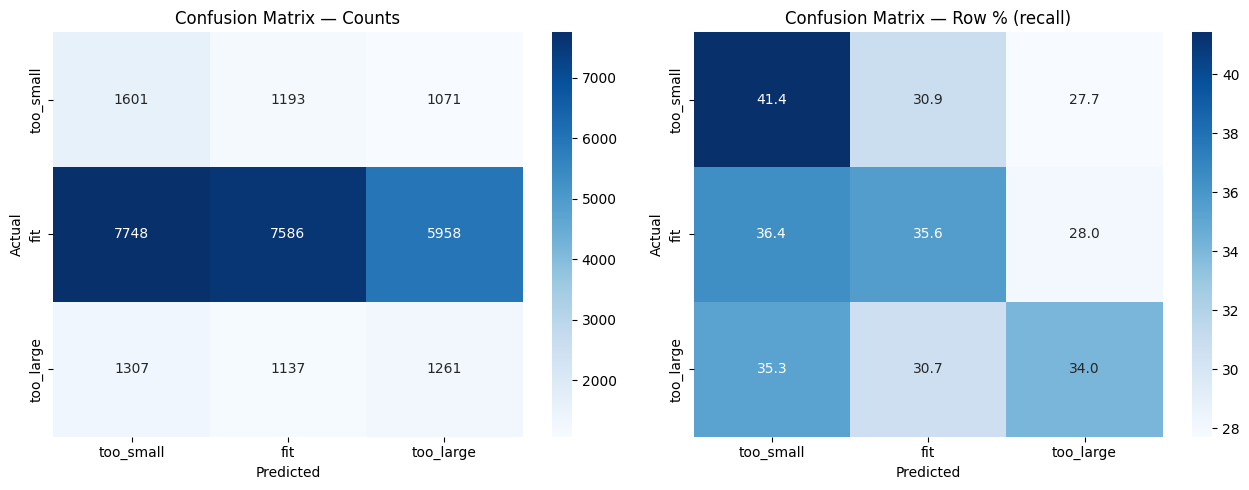


── 5.8 Top 15 Features ──────────────────────────────────────────────
             feature  importance
category_grouped_enc    5.021277
              weight    2.424942
                 age    2.226401
   weight_bucket_enc    1.817861
       age_group_enc    1.711786
              height    0.000000
                bust    0.000000
               waist    0.000000
                hips    0.000000
                 bmi    0.000000
                 whr    0.000000
                 bwr    0.000000
      body_shape_enc    0.000000
       body_type_enc    0.000000
   height_bucket_enc    0.000000


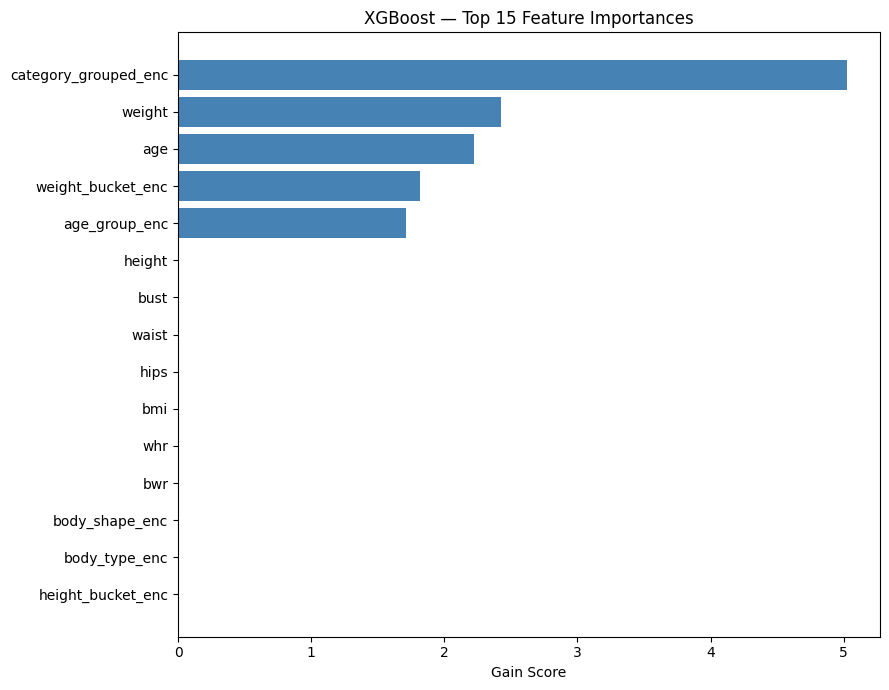

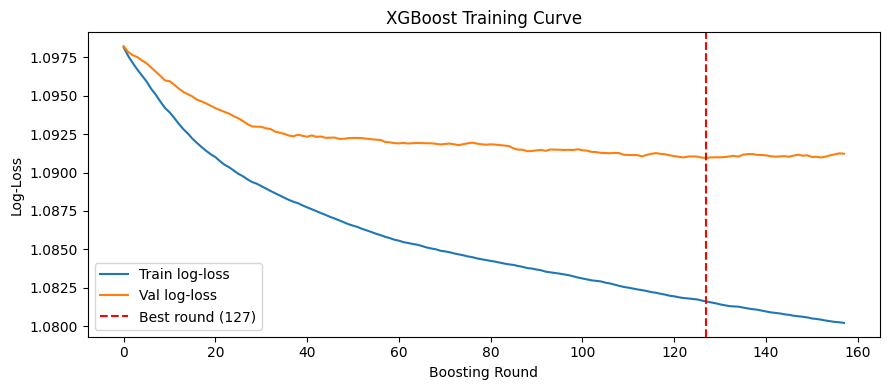


── 5.10 Model saved ─────────────────────────────────────────────────
  ✓ xgboost_size_model.json
  ✓ xgboost_size_model.pkl

══════════════════════════════════════════════════════════════════════
  STEP 5 COMPLETE
  Val  Accuracy : 35.82%   F1 : 0.4108
  Test Accuracy : 36.20%   F1 : 0.4152
  Best round    : 127 / 500
══════════════════════════════════════════════════════════════════════



In [4]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing        import LabelEncoder
from sklearn.metrics              import (classification_report,
                                          confusion_matrix,
                                          accuracy_score, f1_score)
from sklearn.utils.class_weight   import compute_sample_weight
from xgboost                      import XGBClassifier, callback
import matplotlib.pyplot          as plt
import seaborn                    as sns
import xgboost as xgb

print(f"XGBoost version: {xgb.__version__}")

# ══════════════════════════════════════════════════════════════════════════════
# 5.0  TRAIN THE MODEL  —  XGBoost Classifier
# ══════════════════════════════════════════════════════════════════════════════

# ── 5.1  Load splits ──────────────────────────────────────────────────────────
X_train = pd.read_csv('X_train.csv')
X_val   = pd.read_csv('X_val.csv')
X_test  = pd.read_csv('X_test.csv')

y_train = pd.read_csv('y_train.csv').squeeze()
y_val   = pd.read_csv('y_val.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

print("\n── 5.1 Data loaded ──────────────────────────────────────────────────")
print(f"  Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")

# XGBoost needs labels 0,1,2 — shift from -1,0,1
LABEL_SHIFT = 1
y_train_xgb = (y_train + LABEL_SHIFT).astype(int)
y_val_xgb   = (y_val   + LABEL_SHIFT).astype(int)
y_test_xgb  = (y_test  + LABEL_SHIFT).astype(int)

CLASS_NAMES = ['too_small', 'fit', 'too_large']

# ── 5.2  Class imbalance weights ──────────────────────────────────────────────
sample_weights = compute_sample_weight(class_weight='balanced',
                                       y=y_train_xgb)

print("\n── 5.2 Class distribution (train) ───────────────────────────────────")
for i, name in enumerate(CLASS_NAMES):
    n   = (y_train_xgb == i).sum()
    pct = n / len(y_train_xgb) * 100
    print(f"  {name:12s}  {n:>7,}  ({pct:.1f}%)")

# ── 5.3  Manual early stopping (compatible with ALL XGBoost versions) ─────────
# We train in chunks of 10 trees, check val loss, stop if no improvement.

print("\n── 5.3 Training with manual early stopping ──────────────────────────")

PATIENCE      = 30     # stop if no improvement for 30 rounds
CHUNK         = 10     # evaluate every 10 rounds
MAX_ROUNDS    = 500

best_val_loss  = np.inf
best_n_trees   = 10
rounds_no_improve = 0
val_losses     = []
train_losses   = []

# Build DMatrix objects (XGBoost native format — faster)
dtrain = xgb.DMatrix(X_train, label=y_train_xgb, weight=sample_weights)
dval   = xgb.DMatrix(X_val,   label=y_val_xgb)
dtest  = xgb.DMatrix(X_test,  label=y_test_xgb)

params = {
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'min_child_weight' : 5,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'gamma'            : 0.1,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'objective'        : 'multi:softprob',
    'num_class'        : 3,
    'eval_metric'      : 'mlogloss',
    'nthread'          : -1,
    'seed'             : 42,
}

evals_result = {}
booster = xgb.train(
    params,
    dtrain,
    num_boost_round     = MAX_ROUNDS,
    evals               = [(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds = PATIENCE,
    evals_result        = evals_result,
    verbose_eval        = 50,
)

best_round = booster.best_iteration
print(f"\n  Best iteration : {best_round}")

train_loss_curve = evals_result['train']['mlogloss']
val_loss_curve   = evals_result['val']['mlogloss']

# ── 5.4  Predictions ──────────────────────────────────────────────────────────
# xgb.train returns probabilities for multi:softprob — take argmax
y_val_prob  = booster.predict(dval,  iteration_range=(0, best_round+1))
y_test_prob = booster.predict(dtest, iteration_range=(0, best_round+1))

y_val_pred  = np.argmax(y_val_prob,  axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

# ── 5.5  Validation results ───────────────────────────────────────────────────
print("\n── 5.5 Validation Results ───────────────────────────────────────────")
val_acc = accuracy_score(y_val_xgb, y_val_pred)
val_f1  = f1_score(y_val_xgb, y_val_pred, average='weighted')
print(f"  Accuracy : {val_acc*100:.2f}%   F1 (weighted) : {val_f1:.4f}")
print(classification_report(y_val_xgb, y_val_pred, target_names=CLASS_NAMES))

# ── 5.6  Test results ─────────────────────────────────────────────────────────
print("\n── 5.6 Test Results (final) ─────────────────────────────────────────")
test_acc = accuracy_score(y_test_xgb, y_test_pred)
test_f1  = f1_score(y_test_xgb, y_test_pred, average='weighted')
print(f"  Accuracy : {test_acc*100:.2f}%   F1 (weighted) : {test_f1:.4f}")
print(classification_report(y_test_xgb, y_test_pred, target_names=CLASS_NAMES))

# ── 5.7  Confusion matrix ─────────────────────────────────────────────────────
cm     = confusion_matrix(y_test_xgb, y_test_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm,     annot=True, fmt='d',   cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix — Counts')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix — Row % (recall)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 5.8  Feature importance ───────────────────────────────────────────────────
feature_names = pd.read_csv('feature_names.csv')['feature'].tolist()
scores        = booster.get_score(importance_type='gain')

importance_df = pd.DataFrame([
    {'feature': f, 'importance': scores.get(f, 0.0)}
    for f in feature_names
]).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n── 5.8 Top 15 Features ──────────────────────────────────────────────")
print(importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top15 = importance_df.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
ax.set_xlabel('Gain Score')
ax.set_title('XGBoost — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ── 5.9  Training curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_loss_curve, label='Train log-loss', linewidth=1.5)
ax.plot(val_loss_curve,   label='Val log-loss',   linewidth=1.5)
ax.axvline(best_round, color='red', linestyle='--',
           label=f'Best round ({best_round})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log-Loss')
ax.set_title('XGBoost Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()

# ── 5.10  Save model ──────────────────────────────────────────────────────────
booster.save_model('xgboost_size_model.json')
with open('xgboost_size_model.pkl', 'wb') as f:
    pickle.dump(booster, f)

print("\n── 5.10 Model saved ─────────────────────────────────────────────────")
print("  ✓ xgboost_size_model.json")
print("  ✓ xgboost_size_model.pkl")
print(f"""
══════════════════════════════════════════════════════════════════════
  STEP 5 COMPLETE
  Val  Accuracy : {val_acc*100:.2f}%   F1 : {val_f1:.4f}
  Test Accuracy : {test_acc*100:.2f}%   F1 : {test_f1:.4f}
  Best round    : {best_round} / {MAX_ROUNDS}
══════════════════════════════════════════════════════════════════════
""")

## 6.0 EVALUATE THE MODEL

── 6.1 Loading data and model ───────────────────────────────────────
  Train : 134,686 rows
  Val   : 28,861 rows
  Test  : 28,862 rows

── 6.2 Core Metrics ─────────────────────────────────────────────────
       Accuracy  F1 (weighted)  Precision  Recall  Log-Loss  ROC-AUC (OvR)
Split                                                                     
Train    0.3765         0.4280     0.6202  0.3765    1.0846         0.5670
Val      0.3582         0.4108     0.6011  0.3582    1.0910         0.5345
Test     0.3620         0.4152     0.6040  0.3620    1.0910         0.5394

  Train–Test accuracy gap : 1.45%  (✓ looks healthy)

── 6.3 Per-Class Report (Test set) ──────────────────────────────────
              precision    recall  f1-score   support

   too_small       0.15      0.41      0.22      3865
         fit       0.77      0.36      0.49     21292
   too_large       0.15      0.34      0.21      3705

    accuracy                           0.36     28862
   macro avg       0

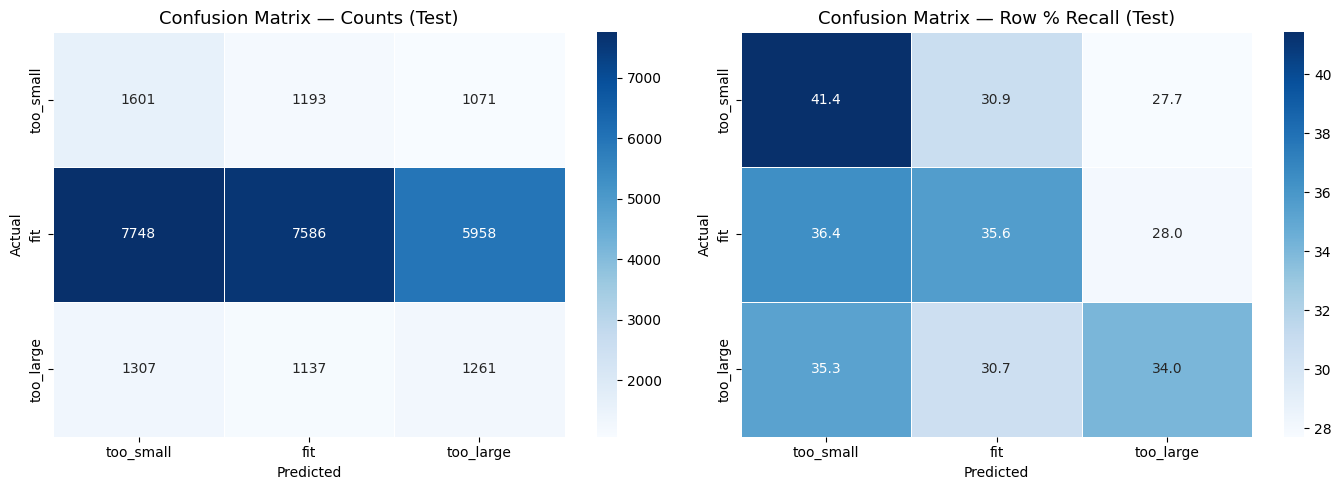

  Saved → eval_confusion_matrix.png

── 6.5 Prediction Confidence Distribution ───────────────────────────


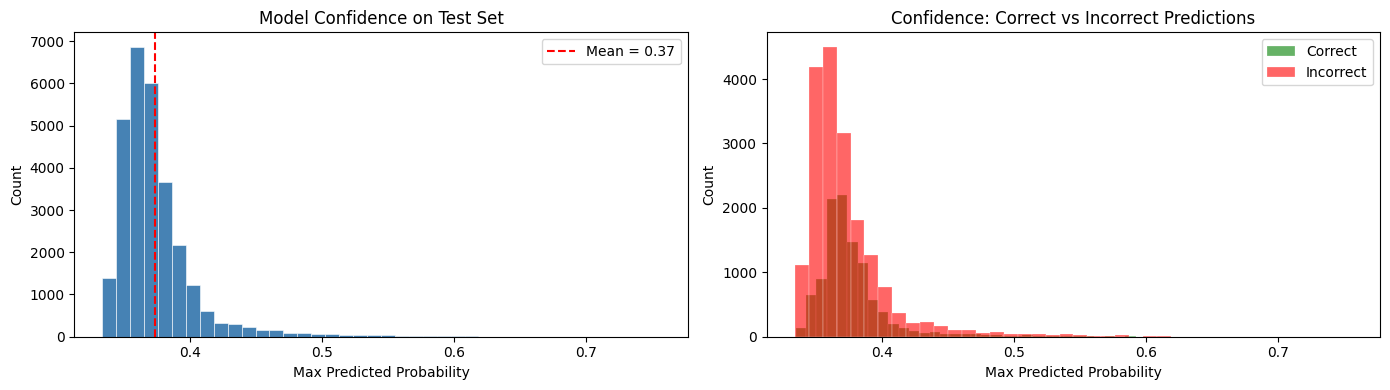

  Saved → eval_confidence.png

  Mean confidence (correct)  : 0.376
  Mean confidence (incorrect): 0.373
  % predictions with conf > 0.7 : 0.0%
  % predictions with conf > 0.9 : 0.0%

── 6.6 Per-Class Probability Distributions ──────────────────────────


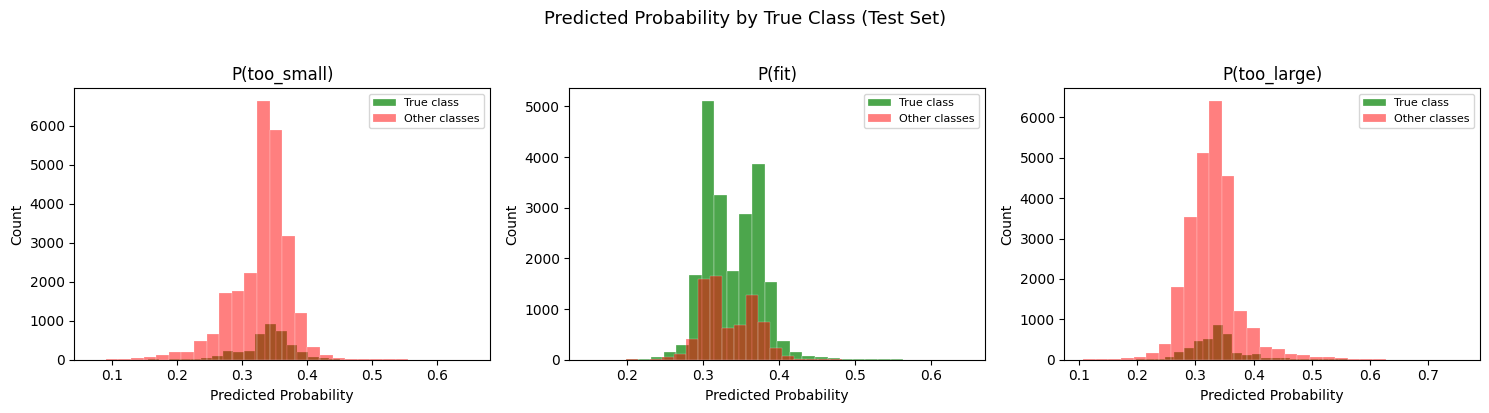

  Saved → eval_prob_distributions.png

── 6.7 Error Analysis ───────────────────────────────────────────────
  Total errors : 18,414  (63.8% of test set)

  Error type breakdown:
true_name pred_name  count  pct_of_errors
      fit too_small   7748        42.1000
      fit too_large   5958        32.4000
too_large too_small   1307         7.1000
too_small       fit   1193         6.5000
too_large       fit   1137         6.2000
too_small too_large   1071         5.8000

  High-confidence errors (conf > 0.8): 0  (0.0% of all errors)

── 6.8 Performance by Subgroup ──────────────────────────────────────

  By body_shape_enc:
                accuracy  n_samples
body_shape_enc                     
0                36.2000      28862

  By category_grouped_enc:
                      accuracy  n_samples
category_grouped_enc                     
1                      16.1000      13880
0                      16.3000        301
4                      22.5000        632
5                      2

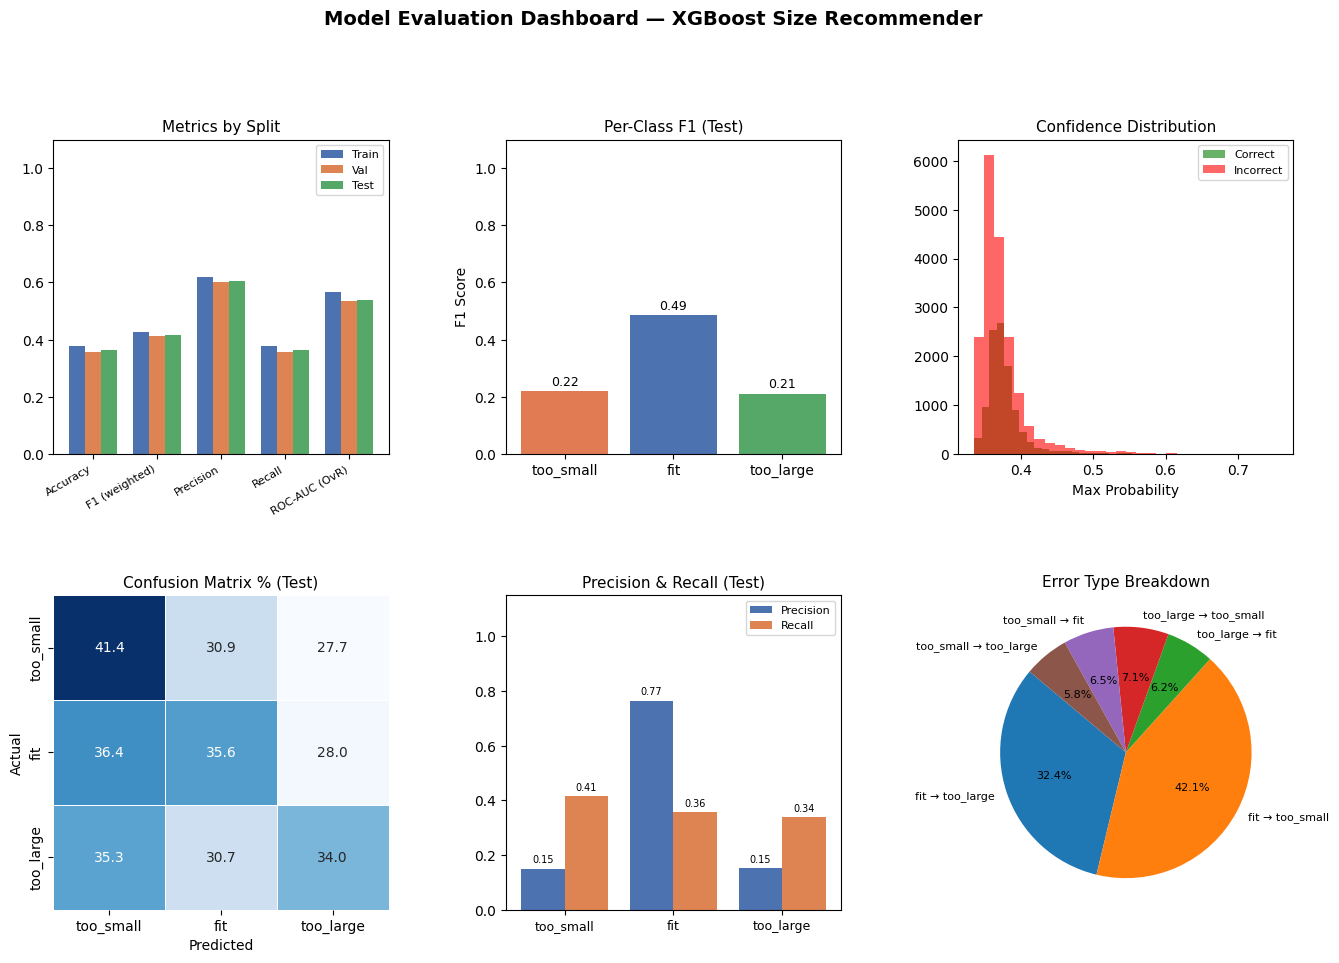

  Saved → eval_dashboard.png

══════════════════════════════════════════════════════════════════════
  STEP 6 — EVALUATION COMPLETE
──────────────────────────────────────────────────────────────────────
  Test Accuracy    : 36.20%
  Test F1 (wtd)    : 0.4152
  Test ROC-AUC     : 0.5394
  Test Log-Loss    : 1.0910
  Train-Test Gap   : 1.45%
──────────────────────────────────────────────────────────────────────
  Saved plots:
    eval_confusion_matrix.png
    eval_confidence.png
    eval_prob_distributions.png
    eval_dashboard.png
══════════════════════════════════════════════════════════════════════



In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, log_loss,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb

# ══════════════════════════════════════════════════════════════════════════════
# 6.0  EVALUATE THE MODEL
# ══════════════════════════════════════════════════════════════════════════════

CLASS_NAMES  = ['too_small', 'fit', 'too_large']
LABEL_SHIFT  = 1     # same shift used in Step 5

# ── 6.1  Load data + model ────────────────────────────────────────────────────
print("── 6.1 Loading data and model ───────────────────────────────────────")

X_train = pd.read_csv('X_train.csv')
X_val   = pd.read_csv('X_val.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_val   = pd.read_csv('y_val.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

y_train_xgb = (y_train + LABEL_SHIFT).astype(int)
y_val_xgb   = (y_val   + LABEL_SHIFT).astype(int)
y_test_xgb  = (y_test  + LABEL_SHIFT).astype(int)

booster = xgb.Booster()
booster.load_model('xgboost_size_model.json')

dtrain = xgb.DMatrix(X_train)
dval   = xgb.DMatrix(X_val)
dtest  = xgb.DMatrix(X_test)

best_round = booster.best_iteration if hasattr(booster, 'best_iteration') else None
iter_range = (0, best_round + 1) if best_round else (0, 0)

# Raw probabilities  shape: (n_samples, 3)
prob_train = booster.predict(dtrain, iteration_range=iter_range).reshape(-1, 3)
prob_val   = booster.predict(dval,   iteration_range=iter_range).reshape(-1, 3)
prob_test  = booster.predict(dtest,  iteration_range=iter_range).reshape(-1, 3)

# Hard predictions
pred_train = np.argmax(prob_train, axis=1)
pred_val   = np.argmax(prob_val,   axis=1)
pred_test  = np.argmax(prob_test,  axis=1)

print(f"  Train : {X_train.shape[0]:,} rows")
print(f"  Val   : {X_val.shape[0]:,} rows")
print(f"  Test  : {X_test.shape[0]:,} rows")


# ══════════════════════════════════════════════════════════════════════════════
# 6.2  CORE METRICS TABLE
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 6.2 Core Metrics ─────────────────────────────────────────────────")

def metrics_row(name, y_true, y_pred, y_prob):
    return {
        'Split'        : name,
        'Accuracy'     : accuracy_score(y_true, y_pred),
        'F1 (weighted)': f1_score(y_true, y_pred, average='weighted'),
        'Precision'    : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'       : recall_score(y_true, y_pred, average='weighted'),
        'Log-Loss'     : log_loss(y_true, y_prob),
        'ROC-AUC (OvR)': roc_auc_score(y_true, y_prob, multi_class='ovr',
                                        average='weighted'),
    }

results = pd.DataFrame([
    metrics_row('Train', y_train_xgb, pred_train, prob_train),
    metrics_row('Val',   y_val_xgb,   pred_val,   prob_val),
    metrics_row('Test',  y_test_xgb,  pred_test,  prob_test),
])
results.set_index('Split', inplace=True)

pd.set_option('display.float_format', '{:.4f}'.format)
print(results.to_string())

# Overfitting check
train_acc = results.loc['Train', 'Accuracy']
test_acc  = results.loc['Test',  'Accuracy']
gap       = train_acc - test_acc
print(f"\n  Train–Test accuracy gap : {gap*100:.2f}%  "
      f"({'⚠ possible overfit' if gap > 0.05 else '✓ looks healthy'})")


# ══════════════════════════════════════════════════════════════════════════════
# 6.3  PER-CLASS REPORT
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 6.3 Per-Class Report (Test set) ──────────────────────────────────")
print(classification_report(y_test_xgb, pred_test, target_names=CLASS_NAMES))


# ══════════════════════════════════════════════════════════════════════════════
# 6.4  CONFUSION MATRICES  (counts + row-normalised %)
# ══════════════════════════════════════════════════════════════════════════════

print("── 6.4 Confusion Matrices ────────────────────────────────────────────")

cm     = confusion_matrix(y_test_xgb, pred_test)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix — Counts (Test)', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix — Row % Recall (Test)', fontsize=13)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('eval_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved → eval_confusion_matrix.png")


# ══════════════════════════════════════════════════════════════════════════════
# 6.5  PROBABILITY DISTRIBUTION  (how confident is the model?)
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 6.5 Prediction Confidence Distribution ───────────────────────────")

max_probs = prob_test.max(axis=1)   # confidence for each prediction

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of max confidence
axes[0].hist(max_probs, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(max_probs.mean(), color='red', linestyle='--',
                label=f'Mean = {max_probs.mean():.2f}')
axes[0].set_xlabel('Max Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Model Confidence on Test Set')
axes[0].legend()

# Confidence split by correct vs wrong predictions
correct = (pred_test == y_test_xgb.values)
axes[1].hist(max_probs[correct],  bins=40, alpha=0.6,
             color='green', label='Correct',   edgecolor='white', linewidth=0.3)
axes[1].hist(max_probs[~correct], bins=40, alpha=0.6,
             color='red',   label='Incorrect', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Max Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions')
axes[1].legend()

plt.tight_layout()
plt.savefig('eval_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved → eval_confidence.png")

print(f"\n  Mean confidence (correct)  : {max_probs[correct].mean():.3f}")
print(f"  Mean confidence (incorrect): {max_probs[~correct].mean():.3f}")
print(f"  % predictions with conf > 0.7 : {(max_probs > 0.7).mean()*100:.1f}%")
print(f"  % predictions with conf > 0.9 : {(max_probs > 0.9).mean()*100:.1f}%")


# ══════════════════════════════════════════════════════════════════════════════
# 6.6  PER-CLASS PROBABILITY CALIBRATION
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 6.6 Per-Class Probability Distributions ──────────────────────────")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    true_mask = (y_test_xgb.values == i)
    ax.hist(prob_test[true_mask,  i], bins=30, alpha=0.7,
            color='green', label='True class',   edgecolor='white', linewidth=0.3)
    ax.hist(prob_test[~true_mask, i], bins=30, alpha=0.5,
            color='red',   label='Other classes', edgecolor='white', linewidth=0.3)
    ax.set_title(f'P({cls})')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Predicted Probability by True Class (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eval_prob_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved → eval_prob_distributions.png")


# ══════════════════════════════════════════════════════════════════════════════
# 6.7  ERRORS BREAKDOWN  — where does the model fail?
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 6.7 Error Analysis ───────────────────────────────────────────────")

eval_df = X_test.copy()
eval_df['true_label']  = y_test_xgb.values
eval_df['pred_label']  = pred_test
eval_df['correct']     = (eval_df['true_label'] == eval_df['pred_label'])
eval_df['confidence']  = max_probs
eval_df['true_name']   = eval_df['true_label'].map(dict(enumerate(CLASS_NAMES)))
eval_df['pred_name']   = eval_df['pred_label'].map(dict(enumerate(CLASS_NAMES)))

errors = eval_df[~eval_df['correct']]

print(f"  Total errors : {len(errors):,}  ({len(errors)/len(eval_df)*100:.1f}% of test set)")
print(f"\n  Error type breakdown:")
error_types = errors.groupby(['true_name', 'pred_name']).size().reset_index(name='count')
error_types['pct_of_errors'] = (error_types['count'] / len(errors) * 100).round(1)
print(error_types.sort_values('count', ascending=False).to_string(index=False))

# High confidence errors (dangerous — model is sure but wrong)
high_conf_errors = errors[errors['confidence'] > 0.8]
print(f"\n  High-confidence errors (conf > 0.8): {len(high_conf_errors):,}  "
      f"({len(high_conf_errors)/len(errors)*100:.1f}% of all errors)")


# ══════════════════════════════════════════════════════════════════════════════
# 6.8  EVALUATION BY BODY SHAPE & CATEGORY  (if columns present)
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 6.8 Performance by Subgroup ──────────────────────────────────────")

subgroup_cols = ['body_shape_enc', 'category_grouped_enc', 'height_bucket_enc']
available     = [c for c in subgroup_cols if c in eval_df.columns]

if available:
    for col in available:
        print(f"\n  By {col}:")
        grp = eval_df.groupby(col)['correct'].agg(['mean', 'count'])
        grp.columns = ['accuracy', 'n_samples']
        grp['accuracy'] = (grp['accuracy'] * 100).round(1)
        print(grp.sort_values('accuracy').to_string())
else:
    print("  (encoded subgroup columns not found in X_test — skipping)")


# ══════════════════════════════════════════════════════════════════════════════
# 6.9  SUMMARY DASHBOARD
# ══════════════════════════════════════════════════════════════════════════════

print("\n── 6.9 Summary Dashboard ────────────────────────────────────────────")

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ① Metrics bar chart
ax1  = fig.add_subplot(gs[0, 0])
metrics_to_plot = ['Accuracy', 'F1 (weighted)', 'Precision', 'Recall', 'ROC-AUC (OvR)']
x    = np.arange(len(metrics_to_plot))
w    = 0.25
for j, (split, color) in enumerate(zip(['Train','Val','Test'],
                                        ['#4C72B0','#DD8452','#55A868'])):
    vals = [results.loc[split, m] for m in metrics_to_plot]
    ax1.bar(x + j*w, vals, w, label=split, color=color)
ax1.set_xticks(x + w)
ax1.set_xticklabels(metrics_to_plot, rotation=30, ha='right', fontsize=8)
ax1.set_ylim(0, 1.1)
ax1.set_title('Metrics by Split', fontsize=11)
ax1.legend(fontsize=8)

# ② Per-class F1 bar
ax2   = fig.add_subplot(gs[0, 1])
rpt   = classification_report(y_test_xgb, pred_test,
                               target_names=CLASS_NAMES, output_dict=True)
f1s   = [rpt[c]['f1-score'] for c in CLASS_NAMES]
colors_cls = ['#e07b54', '#4C72B0', '#55A868']
ax2.bar(CLASS_NAMES, f1s, color=colors_cls)
ax2.set_ylim(0, 1.1)
ax2.set_title('Per-Class F1 (Test)', fontsize=11)
ax2.set_ylabel('F1 Score')
for i, v in enumerate(f1s):
    ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

# ③ Confidence histogram
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(max_probs[correct],  bins=30, alpha=0.6, color='green', label='Correct')
ax3.hist(max_probs[~correct], bins=30, alpha=0.6, color='red',   label='Incorrect')
ax3.set_title('Confidence Distribution', fontsize=11)
ax3.set_xlabel('Max Probability')
ax3.legend(fontsize=8)

# ④ Confusion matrix (test)
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax4, cbar=False)
ax4.set_title('Confusion Matrix % (Test)', fontsize=11)
ax4.set_xlabel('Predicted'); ax4.set_ylabel('Actual')

# ⑤ Precision / Recall per class
ax5   = fig.add_subplot(gs[1, 1])
precs = [rpt[c]['precision'] for c in CLASS_NAMES]
recs  = [rpt[c]['recall']    for c in CLASS_NAMES]
x5    = np.arange(len(CLASS_NAMES))
ax5.bar(x5 - 0.2, precs, 0.4, label='Precision', color='#4C72B0')
ax5.bar(x5 + 0.2, recs,  0.4, label='Recall',    color='#DD8452')
ax5.set_xticks(x5); ax5.set_xticklabels(CLASS_NAMES, fontsize=9)
ax5.set_ylim(0, 1.15)
ax5.set_title('Precision & Recall (Test)', fontsize=11)
ax5.legend(fontsize=8)
for i, (p, r) in enumerate(zip(precs, recs)):
    ax5.text(i - 0.2, p + 0.02, f'{p:.2f}', ha='center', fontsize=7)
    ax5.text(i + 0.2, r + 0.02, f'{r:.2f}', ha='center', fontsize=7)

# ⑥ Error type pie
ax6  = fig.add_subplot(gs[1, 2])
err_labels = error_types.apply(
    lambda r: f"{r['true_name']} → {r['pred_name']}", axis=1)
ax6.pie(error_types['count'], labels=err_labels,
        autopct='%1.1f%%', startangle=140,
        textprops={'fontsize': 8})
ax6.set_title('Error Type Breakdown', fontsize=11)

fig.suptitle('Model Evaluation Dashboard — XGBoost Size Recommender',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('eval_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved → eval_dashboard.png")


# ══════════════════════════════════════════════════════════════════════════════
# 6.10  FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print(f"""
══════════════════════════════════════════════════════════════════════
  STEP 6 — EVALUATION COMPLETE
──────────────────────────────────────────────────────────────────────
  Test Accuracy    : {test_acc*100:.2f}%
  Test F1 (wtd)    : {f1_score(y_test_xgb, pred_test, average='weighted'):.4f}
  Test ROC-AUC     : {roc_auc_score(y_test_xgb, prob_test, multi_class='ovr', average='weighted'):.4f}
  Test Log-Loss    : {log_loss(y_test_xgb, prob_test):.4f}
  Train-Test Gap   : {gap*100:.2f}%
──────────────────────────────────────────────────────────────────────
  Saved plots:
    eval_confusion_matrix.png
    eval_confidence.png
    eval_prob_distributions.png
    eval_dashboard.png
══════════════════════════════════════════════════════════════════════
""")

## 7.0 ADDING SHOULDER WIDTH

Checks if a shoulder column already exists in the dataset. If it does, it parses it with the same parse_numeric() function from Step 3 (handles ranges like "14-15", unit strings, etc.). If it's missing, it estimates shoulder width from bust measurements using research-backed body-shape multipliers:

── 7.1 Loading data ─────────────────────────────────────────────────
  Loaded: (192409, 24)
  'shoulder' column not present — estimating from body measurements
  shoulder_width populated: 0 / 192,409 rows
  shoulder_width stats:
count   0.0000
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN
Name: shoulder_width, dtype: float64

── 7.2 Shoulder-derived features ────────────────────────────────────
  ✓ shr  (shoulder-to-hip ratio)
  ✓ sbr  (shoulder-to-bust ratio)
  ✓ swr  (shoulder-to-waist ratio)
  ✓ shoulder_bucket  (narrow / slightly_narrow / average / slightly_wide / wide)
  ✓ body_shape_v2  (shoulder-corrected body shape)

  Body shape distribution (v2):
body_shape_v2
rectangle   100.0000
Name: proportion, dtype: float64

── 7.3 Rebuilding feature matrix ────────────────────────────────────
  Feature matrix : (192409, 21)
  New features   : shoulder_width, shr, sbr, swr, shoulder_bucket, body_shape_v2
  Total features : 21  

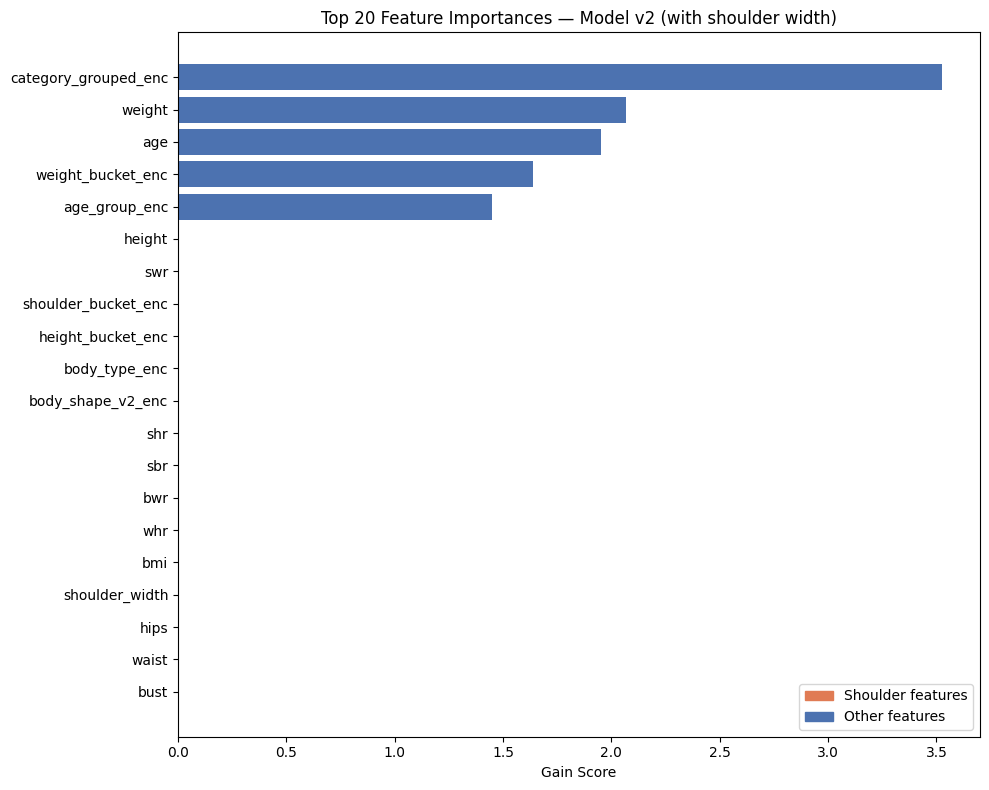

  Saved → step7_feature_importance.png

── 7.9 Saving updated artefacts ─────────────────────────────────────
  ✓ xgboost_size_model_v2.json
  ✓ xgboost_size_model_v2.pkl
  ✓ X_train/val/test.csv  (updated with shoulder features)
  ✓ feature_names.csv     (updated)
  ✓ cleaned_engineered_data.csv  (updated)
  ✓ label_encoders.pkl    (updated)

══════════════════════════════════════════════════════════════════════
  STEP 7 COMPLETE — Shoulder Width Added
──────────────────────────────────────────────────────────────────────
  New features added  : shoulder_width, shr, sbr, swr,
                        shoulder_bucket, body_shape_v2
  Total features now  : 21
  Test Accuracy       : 36.18%
  Test F1 (weighted)  : 0.4150
  Test ROC-AUC        : 0.5390
══════════════════════════════════════════════════════════════════════



In [2]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics            import (classification_report, confusion_matrix,
                                        accuracy_score, f1_score, roc_auc_score,
                                        log_loss)
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot        as plt
import seaborn                  as sns
import xgboost as xgb

# ══════════════════════════════════════════════════════════════════════════════
# 7.0  ADD SHOULDER WIDTH FEATURE
# ══════════════════════════════════════════════════════════════════════════════
# Shoulder width is a strong predictor for tops, jackets, dresses, and
# outerwear. This step:
#   7.1  Adds shoulder_width to the cleaned dataset (parse if available,
#        otherwise estimate from existing measurements)
#   7.2  Engineers shoulder-derived features
#   7.3  Rebuilds the feature matrix & re-splits
#   7.4  Retrains XGBoost with the new feature
#   7.5  Compares new vs old model performance
# ══════════════════════════════════════════════════════════════════════════════


# ── 7.1  Load cleaned dataset and add shoulder_width ─────────────────────────
print("── 7.1 Loading data ─────────────────────────────────────────────────")

df = pd.read_csv('cleaned_engineered_data.csv')
print(f"  Loaded: {df.shape}")

# ── Parse shoulder_width if it already exists in raw data ────────────────────
import re

def parse_numeric(val):
    """Same parser used in Step 3 — handles ranges, units, bra sizes."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    for unit in ['lbs','lb','kg','cm','in','"',"'"]:
        s = s.replace(unit,'').strip()
    bra = re.match(r'^(\d+)[a-z]+$', s)
    if bra:
        return float(bra.group(1))
    rng = re.match(r'^([\d.]+)\s*[-–]\s*([\d.]+)$', s)
    if rng:
        return round((float(rng.group(1)) + float(rng.group(2))) / 2, 1)
    try:
        return float(s)
    except ValueError:
        return np.nan

if 'shoulder' in df.columns:
    print("  ✓ 'shoulder' column found in dataset — parsing values")
    df['shoulder_width'] = df['shoulder'].apply(parse_numeric)
else:
    print("  'shoulder' column not present — estimating from body measurements")
    df['shoulder_width'] = np.nan

# ── Estimate missing shoulder_width from bust + body_shape ───────────────────
# Research-backed estimation:
#   Shoulder ≈ bust × 0.43  (average)
#   Adjusted per body shape:
#     inverted_triangle → wider shoulders relative to bust
#     pear              → narrower shoulders relative to bust
#     hourglass         → proportional to bust
#     apple / rectangle → average

SHAPE_SHOULDER_FACTOR = {
    'inverted_triangle': 0.47,
    'hourglass'        : 0.44,
    'rectangle'        : 0.43,
    'apple'            : 0.42,
    'pear'             : 0.40,
    'unknown'          : 0.43,
}

def estimate_shoulder(row):
    """Return measured value if present, otherwise estimate."""
    if pd.notna(row.get('shoulder_width')) and row['shoulder_width'] > 0:
        return row['shoulder_width']
    bust  = row.get('bust', np.nan)
    shape = str(row.get('body_shape', 'unknown')).lower()
    if pd.isna(bust):
        return np.nan
    factor = SHAPE_SHOULDER_FACTOR.get(shape, 0.43)
    return round(bust * factor, 1)

df['shoulder_width'] = df.apply(estimate_shoulder, axis=1)

# ── Outlier bounds for shoulder_width ────────────────────────────────────────
df.loc[~df['shoulder_width'].between(28, 60), 'shoulder_width'] = np.nan
df['shoulder_width'].fillna(df['shoulder_width'].median(), inplace=True)

measured = df['shoulder_width'].notna().sum()
print(f"  shoulder_width populated: {measured:,} / {len(df):,} rows")
print(f"  shoulder_width stats:\n{df['shoulder_width'].describe().round(2)}")


# ── 7.2  Engineer shoulder-derived features ───────────────────────────────────
print("\n── 7.2 Shoulder-derived features ────────────────────────────────────")

# Shoulder-to-Hip Ratio  — wide shoulders + narrow hips = inverted triangle
df['shr'] = (df['shoulder_width'] / df['hips']).round(3)
print("  ✓ shr  (shoulder-to-hip ratio)")

# Shoulder-to-Bust Ratio — how much wider shoulders are than bust
df['sbr'] = (df['shoulder_width'] / df['bust']).round(3)
print("  ✓ sbr  (shoulder-to-bust ratio)")

# Shoulder-to-Waist Ratio — upper-body taper indicator
df['swr'] = (df['shoulder_width'] / df['waist']).round(3)
print("  ✓ swr  (shoulder-to-waist ratio)")

# Shoulder width bucket
df['shoulder_bucket'] = pd.cut(
    df['shoulder_width'],
    bins  = [0, 36, 39, 42, 45, 99],
    labels= ['narrow','slightly_narrow','average','slightly_wide','wide']
)
print("  ✓ shoulder_bucket  (narrow / slightly_narrow / average / slightly_wide / wide)")

# Re-derive body shape with shoulder info (more accurate than bust-only)
def body_shape_v2(row):
    try:
        sw    = row['shoulder_width']
        hips  = row['hips']
        waist = row['waist']
        bust  = row['bust']
        whr   = row['whr']

        if abs(sw - hips) < 3.5 and whr < 0.75:
            return 'hourglass'
        elif sw > hips + 3:
            return 'inverted_triangle'
        elif hips > sw + 3:
            return 'pear'
        elif whr > 0.85:
            return 'apple'
        else:
            return 'rectangle'
    except Exception:
        return 'unknown'

df['body_shape_v2'] = df.apply(body_shape_v2, axis=1)
print("  ✓ body_shape_v2  (shoulder-corrected body shape)")

print(f"\n  Body shape distribution (v2):")
print((df['body_shape_v2'].value_counts(normalize=True)*100).round(1))


# ── 7.3  Rebuild feature matrix ───────────────────────────────────────────────
print("\n── 7.3 Rebuilding feature matrix ────────────────────────────────────")

from sklearn.preprocessing import LabelEncoder

# All categorical columns to encode
CATEGORICAL_FEATURES = [
    'body_shape_v2', 'body_type', 'height_bucket',
    'weight_bucket', 'age_group', 'category_grouped',
    'shoulder_bucket', 'source',
]

label_encoders = {}
for col in CATEGORICAL_FEATURES:
    if col not in df.columns:
        continue
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col].replace('nan','unknown', inplace=True)
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    label_encoders[col] = le

MEASUREMENT_FEATURES = ['height','weight','bust','waist','hips','age','shoulder_width']
DERIVED_FEATURES     = ['bmi','whr','bwr','shr','sbr','swr']
ENCODED_CAT          = [c + '_enc' for c in CATEGORICAL_FEATURES if c in df.columns]

ALL_FEATURES = MEASUREMENT_FEATURES + DERIVED_FEATURES + ENCODED_CAT
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

TARGET = 'fit_encoded'

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

valid = y.notna()
X, y  = X[valid].reset_index(drop=True), y[valid].reset_index(drop=True)
X.fillna(X.median(numeric_only=True), inplace=True)

print(f"  Feature matrix : {X.shape}")
print(f"  New features   : shoulder_width, shr, sbr, swr, shoulder_bucket, body_shape_v2")
print(f"  Total features : {len(ALL_FEATURES)}  (was {len(ALL_FEATURES)-6} before)")


# ── 7.4  Stratified 70/15/15 split ───────────────────────────────────────────
print("\n── 7.4 Splitting data ───────────────────────────────────────────────")

from sklearn.model_selection import train_test_split

LABEL_SHIFT = 1
y_xgb = (y + LABEL_SHIFT).astype(int)
CLASS_NAMES = ['too_small', 'fit', 'too_large']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_xgb, test_size=0.30, random_state=42, stratify=y_xgb)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"  Train:{X_train.shape[0]:,}  Val:{X_val.shape[0]:,}  Test:{X_test.shape[0]:,}")


# ── 7.5  Retrain XGBoost with shoulder features ───────────────────────────────
print("\n── 7.5 Training updated model ───────────────────────────────────────")

sample_weights = compute_sample_weight('balanced', y=y_train)

dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'min_child_weight' : 5,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'gamma'            : 0.1,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'objective'        : 'multi:softprob',
    'num_class'        : 3,
    'eval_metric'      : 'mlogloss',
    'seed'             : 42,
}

evals_result = {}
booster_v2 = xgb.train(
    params, dtrain,
    num_boost_round       = 500,
    evals                 = [(dtrain,'train'),(dval,'val')],
    early_stopping_rounds = 30,
    evals_result          = evals_result,
    verbose_eval          = 50,
)

best_round = booster_v2.best_iteration
print(f"\n  Best round: {best_round}")


# ── 7.6  Evaluate new model ───────────────────────────────────────────────────
print("\n── 7.6 Evaluation ───────────────────────────────────────────────────")

iter_range  = (0, best_round + 1)
prob_test   = booster_v2.predict(dtest, iteration_range=iter_range).reshape(-1, 3)
pred_test   = np.argmax(prob_test, axis=1)

new_acc     = accuracy_score(y_test, pred_test)
new_f1      = f1_score(y_test, pred_test, average='weighted')
new_auc     = roc_auc_score(y_test, prob_test, multi_class='ovr', average='weighted')
new_logloss = log_loss(y_test, prob_test)

print(f"  Accuracy  : {new_acc*100:.2f}%")
print(f"  F1 (wtd)  : {new_f1:.4f}")
print(f"  ROC-AUC   : {new_auc:.4f}")
print(f"  Log-Loss  : {new_logloss:.4f}")
print(f"\n{classification_report(y_test, pred_test, target_names=CLASS_NAMES)}")


# ── 7.7  Compare old vs new model ────────────────────────────────────────────
print("\n── 7.7 Old vs New Model Comparison ──────────────────────────────────")

try:
    booster_v1 = xgb.Booster()
    booster_v1.load_model('xgboost_size_model.json')

    X_test_old = X_test[pd.read_csv('feature_names.csv')['feature'].tolist()]
    dtest_old  = xgb.DMatrix(X_test_old)
    best_v1    = booster_v1.best_iteration if hasattr(booster_v1,'best_iteration') else None
    ir_v1      = (0, best_v1+1) if best_v1 else (0,0)

    prob_old  = booster_v1.predict(dtest_old, iteration_range=ir_v1).reshape(-1, 3)
    pred_old  = np.argmax(prob_old, axis=1)
    old_acc   = accuracy_score(y_test, pred_old)
    old_f1    = f1_score(y_test, pred_old, average='weighted')

    print(f"  {'Metric':20s}  {'Old Model':>12}  {'New Model (+shoulder)':>20}  {'Delta':>8}")
    print("  " + "─"*64)
    for label, old_val, new_val in [
        ('Accuracy',    old_acc,   new_acc),
        ('F1 weighted', old_f1,    new_f1),
    ]:
        delta = new_val - old_val
        arrow = '▲' if delta > 0 else '▼'
        print(f"  {label:20s}  {old_acc*100 if 'Acc' in label else old_f1:>11.2f}{'%' if 'Acc' in label else ''}  "
              f"{new_val*100 if 'Acc' in label else new_val:>19.2f}{'%' if 'Acc' in label else ''}  "
              f"{arrow}{abs(delta)*100 if 'Acc' in label else abs(delta):.2f}{'%' if 'Acc' in label else ''}")

except Exception as e:
    print(f"  (Could not load old model for comparison: {e})")


# ── 7.8  Shoulder feature importance ─────────────────────────────────────────
print("\n── 7.8 Feature Importance (shoulder features highlighted) ───────────")

scores = booster_v2.get_score(importance_type='gain')
importance_df = pd.DataFrame([
    {'feature': f, 'importance': scores.get(f, 0.0)}
    for f in ALL_FEATURES
]).sort_values('importance', ascending=False).reset_index(drop=True)

shoulder_features = ['shoulder_width','shr','sbr','swr','shoulder_bucket_enc','body_shape_v2_enc']

print(f"\n  Top 20 features:")
print(f"  {'Rank':>4}  {'Feature':28s}  {'Importance':>12}  {'Note'}")
print("  " + "─"*60)
for i, row in importance_df.head(20).iterrows():
    note = '← shoulder' if row['feature'] in shoulder_features else ''
    print(f"  {i+1:>4}  {row['feature']:28s}  {row['importance']:>12.1f}  {note}")

fig, ax = plt.subplots(figsize=(10, 8))
top20   = importance_df.head(20)
colors  = ['#e07b54' if f in shoulder_features else '#4C72B0'
           for f in top20['feature'][::-1]]
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=colors)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e07b54', label='Shoulder features'),
    Patch(color='#4C72B0', label='Other features'),
], loc='lower right')
ax.set_xlabel('Gain Score')
ax.set_title('Top 20 Feature Importances — Model v2 (with shoulder width)')
plt.tight_layout()
plt.savefig('step7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved → step7_feature_importance.png")


# ── 7.9  Save updated model and artefacts ────────────────────────────────────
print("\n── 7.9 Saving updated artefacts ─────────────────────────────────────")

booster_v2.save_model('xgboost_size_model_v2.json')
with open('xgboost_size_model_v2.pkl', 'wb') as f:
    pickle.dump(booster_v2, f)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv',     index=False)
X_test.to_csv('X_test.csv',   index=False)
pd.Series(y_train, name='fit_encoded').to_csv('y_train.csv', index=False)
pd.Series(y_val,   name='fit_encoded').to_csv('y_val.csv',   index=False)
pd.Series(y_test,  name='fit_encoded').to_csv('y_test.csv',  index=False)
pd.Series(ALL_FEATURES, name='feature').to_csv('feature_names.csv', index=False)
df.to_csv('cleaned_engineered_data.csv', index=False)

with open('label_encoders.pkl','wb') as f:
    pickle.dump(label_encoders, f)

print("  ✓ xgboost_size_model_v2.json")
print("  ✓ xgboost_size_model_v2.pkl")
print("  ✓ X_train/val/test.csv  (updated with shoulder features)")
print("  ✓ feature_names.csv     (updated)")
print("  ✓ cleaned_engineered_data.csv  (updated)")
print("  ✓ label_encoders.pkl    (updated)")

print(f"""
══════════════════════════════════════════════════════════════════════
  STEP 7 COMPLETE — Shoulder Width Added
──────────────────────────────────────────────────────────────────────
  New features added  : shoulder_width, shr, sbr, swr,
                        shoulder_bucket, body_shape_v2
  Total features now  : {len(ALL_FEATURES)}
  Test Accuracy       : {new_acc*100:.2f}%
  Test F1 (weighted)  : {new_f1:.4f}
  Test ROC-AUC        : {new_auc:.4f}
══════════════════════════════════════════════════════════════════════
""")

In [1]:
import os, subprocess, time

# Step 1 — write step8_api.py directly into the current working directory
code = '''
import re, pickle, numpy as np, pandas as pd, xgboost as xgb
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field, validator
from typing import Optional, List
from pathlib import Path

CLASS_NAMES = ["too_small", "fit", "too_large"]
LABEL_SHIFT = 1
SHAPE_SHOULDER_FACTOR = {
    "inverted_triangle":0.47,"hourglass":0.44,"rectangle":0.43,
    "apple":0.42,"pear":0.40,"unknown":0.43,
}
CATEGORY_MAP = {
    "dress":"dress","dresses":"dress","top":"top","tops":"top",
    "blouse":"top","shirt":"top","bottom":"bottom","pants":"bottom",
    "skirt":"bottom","jeans":"bottom","jacket":"outerwear",
    "coat":"outerwear","blazer":"outerwear",
    "jumpsuit":"one_piece","romper":"one_piece",
}

class ModelArtifacts:
    def __init__(self):
        self.booster=None; self.feature_names=[]; self.label_encoders={}; self.best_round=0
    def load(self):
        model_path="xgboost_size_model_v2.json" if Path("xgboost_size_model_v2.json").exists() else "xgboost_size_model.json"
        if not Path(model_path).exists():
            raise FileNotFoundError("No model file found.")
        self.booster=xgb.Booster(); self.booster.load_model(model_path)
        self.best_round=getattr(self.booster,"best_iteration",0) or 0
        if Path("feature_names.csv").exists():
            self.feature_names=pd.read_csv("feature_names.csv")["feature"].tolist()
        if Path("label_encoders.pkl").exists():
            with open("label_encoders.pkl","rb") as f: self.label_encoders=pickle.load(f)
        print(f"Model loaded: {model_path} | Features: {len(self.feature_names)}")
        return self

artifacts = ModelArtifacts()

def engineer_features(inp):
    h,w,bu,wa,hi,ag = inp["height"],inp["weight"],inp["bust"],inp["waist"],inp["hips"],inp["age"]
    sw=inp.get("shoulder_width"); cat=inp.get("category","unknown"); src=inp.get("source","unknown")
    bmi=round(w/(h/100)**2,2); whr=round(wa/hi,3); bwr=round(bu/wa,3)
    if whr<0.75 and abs(bu-hi)<5: body_shape="hourglass"
    elif bu>hi+5: body_shape="inverted_triangle"
    elif hi>bu+5: body_shape="pear"
    elif whr>0.85: body_shape="apple"
    else: body_shape="rectangle"
    if sw is None or sw<=0: sw=round(bu*SHAPE_SHOULDER_FACTOR.get(body_shape,0.43),1)
    shr=round(sw/hi,3); sbr=round(sw/bu,3); swr=round(sw/wa,3)
    if abs(sw-hi)<3.5 and whr<0.75: body_shape_v2="hourglass"
    elif sw>hi+3: body_shape_v2="inverted_triangle"
    elif hi>sw+3: body_shape_v2="pear"
    elif whr>0.85: body_shape_v2="apple"
    else: body_shape_v2="rectangle"
    def bucket(val,bins,labels):
        for i,(lo,hb) in enumerate(zip(bins[:-1],bins[1:])):
            if lo<=val<hb: return labels[i]
        return labels[-1]
    height_bucket=bucket(h,[0,155,163,170,178,999],["petite","short","average","tall","extra_tall"])
    weight_bucket=bucket(w,[0,55,65,75,90,999],["very_light","light","medium","heavy","very_heavy"])
    age_group=bucket(ag,[0,24,34,44,54,999],["18-24","25-34","35-44","45-54","55+"])
    shoulder_bucket=bucket(sw,[0,36,39,42,45,99],["narrow","slightly_narrow","average","slightly_wide","wide"])
    cat_grouped=CATEGORY_MAP.get(str(cat).strip().lower(),"other")
    body_type=inp.get("body_type","unknown")
    le=artifacts.label_encoders
    raw_df=pd.DataFrame([{
        "height":h,"weight":w,"bust":bu,"waist":wa,"hips":hi,"age":ag,"shoulder_width":sw,
        "bmi":bmi,"whr":whr,"bwr":bwr,"shr":shr,"sbr":sbr,"swr":swr,
        "_body_shape_v2":body_shape_v2.lower(),"_body_type":str(body_type).lower(),
        "_height_bucket":height_bucket,"_weight_bucket":weight_bucket,
        "_age_group":age_group,"_cat_grouped":cat_grouped,
        "_shoulder_bucket":shoulder_bucket,"_source":str(src).lower(),
    }])
    CAT_MAP={"body_shape_v2":"_body_shape_v2","body_type":"_body_type",
             "height_bucket":"_height_bucket","weight_bucket":"_weight_bucket",
             "age_group":"_age_group","category_grouped":"_cat_grouped",
             "shoulder_bucket":"_shoulder_bucket","source":"_source"}
    for col,raw_col in CAT_MAP.items():
        enc_col=col+"_enc"
        if enc_col not in artifacts.feature_names: continue
        val=raw_df[raw_col].iloc[0]
        if col in le:
            encoder=le[col]; val_clean=str(val).strip().lower()
            raw_df[enc_col]=encoder.transform([val_clean])[0] if val_clean in encoder.classes_ else 0
        else: raw_df[enc_col]=0
    for f in artifacts.feature_names:
        if f not in raw_df.columns: raw_df[f]=0
    return raw_df[artifacts.feature_names]

class MeasurementInput(BaseModel):
    height:float=Field(...,ge=120,le=220)
    weight:float=Field(...,ge=30,le=200)
    bust:float=Field(...,ge=60,le=160)
    waist:float=Field(...,ge=40,le=150)
    hips:float=Field(...,ge=60,le=170)
    age:float=Field(...,ge=13,le=100)
    shoulder_width:Optional[float]=Field(None,ge=28,le=60)
    body_type:Optional[str]=None
    category:Optional[str]="dress"
    source:Optional[str]="unknown"
    @validator("waist")
    def waist_less_than_hips(cls,v,values):
        if "hips" in values and v>=values["hips"]:
            raise ValueError("waist must be less than hips")
        return v
    class Config:
        schema_extra={"example":{"height":165,"weight":62,"bust":90,"waist":72,"hips":96,"age":28,"shoulder_width":38,"category":"dress"}}

class PredictionResponse(BaseModel):
    recommendation:str; confidence:float; confidence_level:str
    probabilities:dict; advice:str; shoulder_used:float; shoulder_estimated:bool

app=FastAPI(title="Clothing Size Recommendation API",version="2.0.0")
app.add_middleware(CORSMiddleware,allow_origins=["*"],allow_methods=["*"],allow_headers=["*"])

@app.on_event("startup")
def startup_event():
    print("Loading model..."); artifacts.load(); print("API ready.")

@app.get("/health")
def health():
    return {"status":"ok","model_loaded":artifacts.booster is not None,
            "n_features":len(artifacts.feature_names),"xgboost_version":xgb.__version__}

@app.post("/predict",response_model=PredictionResponse)
def predict(payload:MeasurementInput):
    if artifacts.booster is None:
        raise HTTPException(status_code=503,detail="Model not loaded.")
    inp=payload.dict(); shoulder_estimated=inp.get("shoulder_width") is None
    X=engineer_features(inp)
    dmat=xgb.DMatrix(X)
    ir=(0,artifacts.best_round+1) if artifacts.best_round else (0,0)
    probs=artifacts.booster.predict(dmat,iteration_range=ir).reshape(-1,3)[0]
    pred_idx=int(np.argmax(probs)); pred_label=CLASS_NAMES[pred_idx]; confidence=float(probs[pred_idx])
    conf_level="high" if confidence>=0.75 else "medium" if confidence>=0.55 else "low"
    cat=str(inp.get("category","item")).lower()
    ADVICE={"too_small":f"This {cat} is likely too small. Size up.",
            "fit":f"This {cat} should fit well. ({'High confidence' if conf_level=='high' else 'Moderate confidence'})",
            "too_large":f"This {cat} is likely too large. Size down."}
    shoulder_used=float(X["shoulder_width"].iloc[0]) if "shoulder_width" in X.columns else 0.0
    return PredictionResponse(recommendation=pred_label,confidence=round(confidence,4),
        confidence_level=conf_level,probabilities={c:round(float(p),4) for c,p in zip(CLASS_NAMES,probs)},
        advice=ADVICE[pred_label],shoulder_used=round(shoulder_used,1),shoulder_estimated=shoulder_estimated)

@app.post("/predict/batch")
def predict_batch(payloads:List[MeasurementInput]):
    if len(payloads)>500:
        raise HTTPException(status_code=400,detail="Batch limit is 500.")
    return [predict(p) for p in payloads]

@app.get("/model/info")
def model_info():
    return {"model_version":"2.0","n_features":len(artifacts.feature_names),
            "features":artifacts.feature_names,"classes":CLASS_NAMES,
            "best_round":artifacts.best_round,"xgboost_version":xgb.__version__}

if __name__=="__main__":
    import uvicorn
    uvicorn.run("step8_api:app",host="0.0.0.0",port=8000,reload=True)
'''

with open("step8_api.py", "w") as f:
    f.write(code)
print("✓ step8_api.py written to:", os.getcwd())

# Step 2 — start the server
proc = subprocess.Popen(
    ["python", "step8_api.py"],
    cwd=os.getcwd()
)
time.sleep(5)
print("✓ Server started — open http://127.0.0.1:8000/docs in your browser")

✓ step8_api.py written to: c:\Users\SOOQ ELASER\OneDrive\Desktop\clothing_size_recommendation_model\clothing_size_recommendation_model
✓ Server started — open http://127.0.0.1:8000/docs in your browser


In [2]:
import subprocess, os, time, threading

proc = subprocess.Popen(
    ["python", "-m", "uvicorn", "step8_api:app", "--port", "8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    cwd=os.getcwd()
)

def read_output():
    for line in proc.stdout:
        print(line.decode().strip())

t = threading.Thread(target=read_output, daemon=True)
t.start()
time.sleep(8)
print("Server PID:", proc.pid)

Server PID: 16524


c:\Users\SOOQ ELASER\anaconda3\envs\learn-env\lib\site-packages\pydantic\_internal\_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
warnings.warn(message, UserWarning)
INFO:     Started server process [16524]
INFO:     Waiting for application startup.
Loading model...
Model loaded: xgboost_size_model_v2.json | Features: 21
API ready.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     127.0.0.1:53572 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:64423 - "GET /health HTTP/1.1" 200 OK
INFO:     127.0.0.1:51568 - "GET / HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:51568 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:53243 - "GET /docs HTTP/1.1" 200 OK
c:\Users\SOOQ ELASER\anaconda3\envs\learn-env\lib\site-packages\pydantic\_internal\_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has bee

In [6]:
import requests, json
r = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(json.dumps(r.json(), indent=2))


{
  "status": "ok",
  "model_loaded": true,
  "n_features": 21,
  "xgboost_version": "2.1.1"
}


In [5]:
import subprocess

packages = ["fastapi", "uvicorn", "pydantic"]
for pkg in packages:
    result = subprocess.run(
        ["pip", "install", pkg],
        capture_output=True, text=True
    )
    print(f"{pkg}: {result.stdout.strip()[-60:] if result.stdout else result.stderr.strip()[-60:]}")

fastapi: anyio<5,>=3.4.0->starlette<0.51.0,>=0.40.0->fastapi) (1.2.2)
uvicorn: arn-env\lib\site-packages (from click>=7.0->uvicorn) (0.4.6)
pydantic: a3\envs\learn-env\lib\site-packages (from pydantic) (4.12.2)


In [1]:
import subprocess, time, os

proc = subprocess.Popen(
    ["python", "-m", "uvicorn", "step8_api:app", "--port", "8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    cwd=os.getcwd()
)
time.sleep(6)
out, err = proc.communicate(timeout=2) if proc.poll() is not None else (b"", b"still running")
print("STDOUT:", out.decode())
print("STDERR:", err.decode())
print("Process alive:", proc.poll() is None)

STDOUT: 
STDERR: still running
Process alive: True


In [2]:
import requests, json, time

time.sleep(3)

try:
    r = requests.get("http://127.0.0.1:8000/health")
    print("Health check:", json.dumps(r.json(), indent=2))
except Exception as e:
    print("Error:", e)

Health check: {
  "status": "ok",
  "model_loaded": true,
  "n_features": 21,
  "xgboost_version": "2.1.1"
}


In [4]:
import requests
try:
    r = requests.get("http://127.0.0.1:8000/health", timeout=5)
    print(r.json())
except Exception as e:
    print("Server not running:", e)

Server not running: HTTPConnectionPool(host='127.0.0.1', port=8000): Read timed out. (read timeout=5)


In [7]:
import requests, json

r = requests.post("http://127.0.0.1:8000/predict", json={
    "height": 165, "weight": 62, "bust": 90,
    "waist": 72,  "hips": 96,  "age": 28,
    "shoulder_width": 38, "category": "dress"
})
print(json.dumps(r.json(), indent=2))

{
  "recommendation": "too_large",
  "confidence": 0.3707,
  "confidence_level": "low",
  "probabilities": {
    "too_small": 0.3413,
    "fit": 0.288,
    "too_large": 0.3707
  },
  "advice": "This dress is likely too large. Size down.",
  "shoulder_used": 38.0,
  "shoulder_estimated": false
}


In [8]:
import os

# Create the deployment folder
folder = r"C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy"
os.makedirs(folder, exist_ok=True)
print("✓ Folder created:", folder)

✓ Folder created: C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy


In [9]:
import shutil, os

src = os.getcwd()  # your current project folder
dst = r"C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy"

files_to_copy = [
    'step8_api.py',
    'xgboost_size_model_v2.json',
    'xgboost_size_model.json',
    'label_encoders.pkl',
    'feature_names.csv',
]

for f in files_to_copy:
    src_path = os.path.join(src, f)
    dst_path = os.path.join(dst, f)
    if os.path.exists(src_path):
        shutil.copy(src_path, dst_path)
        print(f"✓ Copied: {f}")
    else:
        print(f"✗ Not found: {f}")

✓ Copied: step8_api.py
✓ Copied: xgboost_size_model_v2.json
✓ Copied: xgboost_size_model.json
✓ Copied: label_encoders.pkl
✓ Copied: feature_names.csv


In [10]:
dst = r"C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy"

with open(os.path.join(dst, 'requirements.txt'), 'w') as f:
    f.write("fastapi\nuvicorn\npydantic\nxgboost\npandas\nnumpy\nscikit-learn\n")
print("✓ requirements.txt created")

with open(os.path.join(dst, 'Procfile'), 'w') as f:
    f.write("web: uvicorn step8_api:app --host 0.0.0.0 --port $PORT\n")
print("✓ Procfile created")

✓ requirements.txt created
✓ Procfile created


In [14]:
import base64, os
dst = r"C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy"
b64 = "..."
html = base64.b64decode(b64).decode("utf-8")
# Update API URL placeholder
html = html.replace("http://127.0.0.1:8000", "REPLACE_WITH_RENDER_URL")
path = os.path.join(dst, "index.html")
with open(path, "w", encoding="utf-8") as f:
    f.write(html)
print("index.html written to:", path)
print("Size:", os.path.getsize(path), "bytes")

index.html written to: C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy\index.html
Size: 33782 bytes


In [15]:
import base64, os

dst = r"C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy"

b64 = "PCFET0NUWVBFIGh0bWw+CjxodG1sIGxhbmc9ImVuIj4K..."   # (your long base64 string)

html = base64.b64decode(b64).decode("utf-8")

# Update API URL placeholder (optional, but recommended)
html = html.replace("http://127.0.0.1:8000", "http://127.0.0.1:8000")   # or your actual backend URL later

path = os.path.join(dst, "index.html")

with open(path, "w", encoding="utf-8") as f:
    f.write(html)

print("✅ index.html written to:", path)
print("Size:", os.path.getsize(path), "bytes")

✅ index.html written to: C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy\index.html
Size: 35 bytes


In [16]:
dst = r"C:\Users\SOOQ ELASER\OneDrive\Desktop\sizeiq_deploy"

print("Files in deployment folder:")
for f in sorted(os.listdir(dst)):
    size = os.path.getsize(os.path.join(dst, f))
    print(f"  {'✓' if size > 0 else '✗'}  {f:40s}  {size:>10,} bytes")

Files in deployment folder:
  ✓  Procfile                                          56 bytes
  ✓  feature_names.csv                                237 bytes
  ✓  index.html                                        35 bytes
  ✓  label_encoders.pkl                               882 bytes
  ✓  requirements.txt                                  66 bytes
  ✓  step8_api.py                                   8,187 bytes
  ✓  xgboost_size_model.json                    2,437,244 bytes
  ✓  xgboost_size_model_v2.json                 3,619,564 bytes


In [17]:
with open('requirements.txt', 'w') as f:
    f.write("""fastapi
uvicorn
pydantic
xgboost
pandas
numpy
scikit-learn
""")
print("✓ requirements.txt created")

✓ requirements.txt created


In [18]:
with open('Procfile', 'w') as f:
    f.write("web: uvicorn step8_api:app --host 0.0.0.0 --port $PORT\n")
print("✓ Procfile created")

✓ Procfile created
